In [77]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kaavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [78]:
import kaggle

kaggle.api.authenticate()

kaggle.api.dataset_download_files('goyaladi/twitter-bot-detection-dataset', path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/goyaladi/twitter-bot-detection-dataset


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bot_detection_data.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(50000, 11)
   User ID        Username                                              Tweet  \
0   132131           flong  Station activity person against natural majori...   
1   289683  hinesstephanie  Authority research natural life material staff...   
2   779715      roberttran  Manage whose quickly especially foot none to g...   
3   696168          pmason  Just cover eight opportunity strong policy which.   
4   704441          noah87                      Animal sign six data good or.   

   Retweet Count  Mention Count  Follower Count  Verified  Bot Label  \
0             85              1            2353     False          1   
1             55              5            9617      True          0   
2              6              2            4363      True          0   
3             54              5            2242      True          1   
4             26              3            8438     False          1   

       Location           Created At            Hashtags  
0     Adk

C:\Users\kaavy\AppData\Local\Temp\ipykernel_16956\2084143914.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])


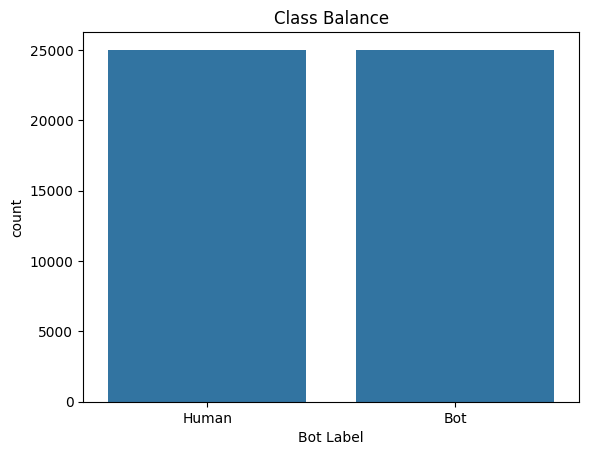

Bot Label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [80]:
ax = sns.countplot(x='Bot Label', data=df)
ax.set_xticklabels(['Human', 'Bot'])
plt.title('Class Balance')
plt.show()
print(df['Bot Label'].value_counts(normalize=True).round(3))


C:\Users\kaavy\AppData\Local\Temp\ipykernel_16956\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])
C:\Users\kaavy\AppData\Local\Temp\ipykernel_16956\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])
C:\Users\kaavy\AppData\Local\Temp\ipykernel_16956\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])


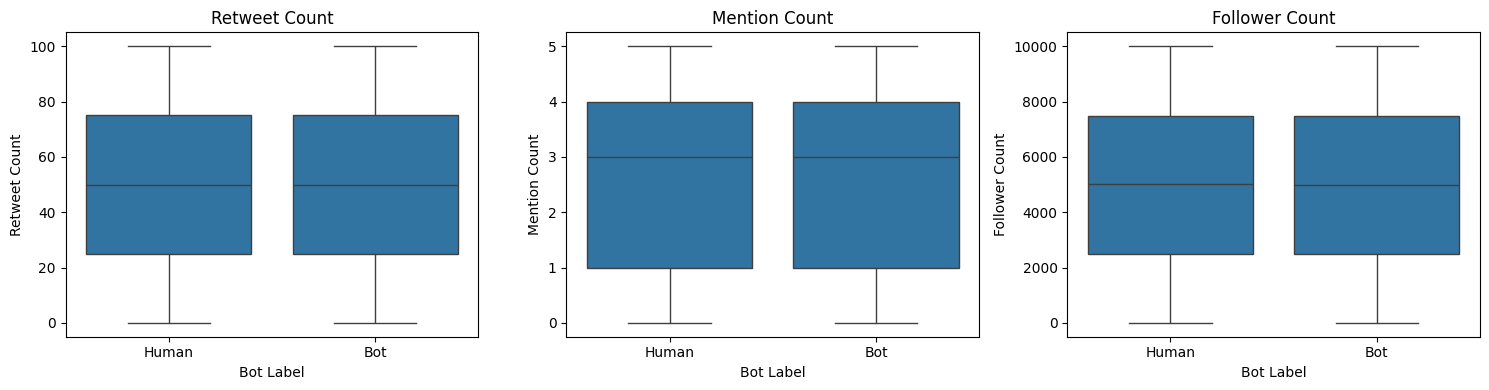

In [81]:
num_cols = ['Retweet Count', 'Mention Count', 'Follower Count']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Bot Label', y=col, data=df, ax=ax)
    ax.set_xticklabels(['Human', 'Bot'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


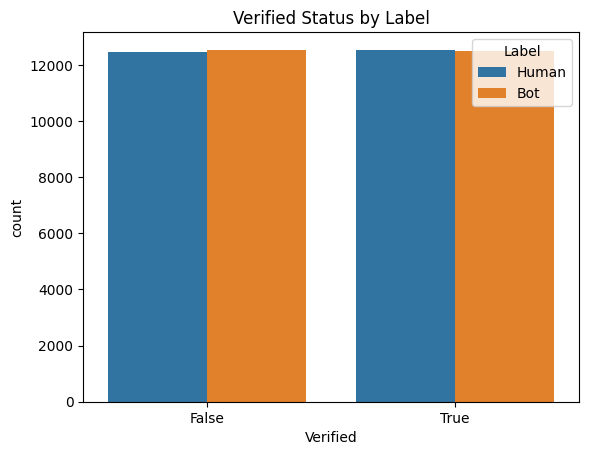

In [82]:
sns.countplot(x='Verified', hue='Bot Label', data=df)
plt.title('Verified Status by Label')
plt.legend(title='Label', labels=['Human', 'Bot'])
plt.show()


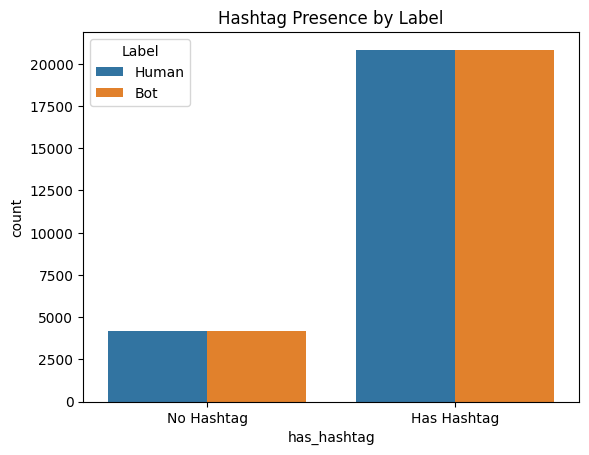

In [83]:
df['has_hashtag'] = df['Hashtags'].notna().astype(int)
sns.countplot(x='has_hashtag', hue='Bot Label', data=df)
plt.title('Hashtag Presence by Label')
plt.xticks([0, 1], ['No Hashtag', 'Has Hashtag'])
plt.legend(title='Label', labels=['Human', 'Bot'])
plt.show()


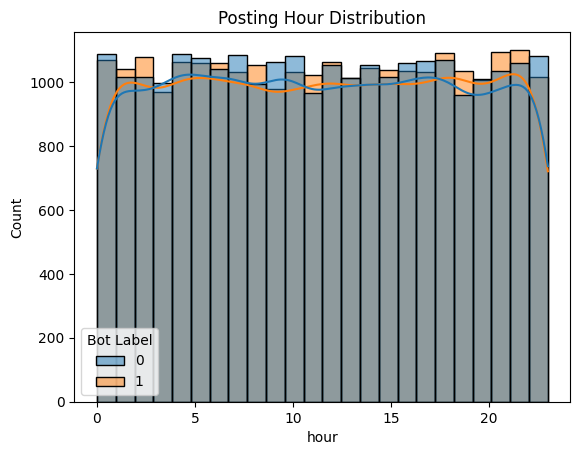

In [84]:
df['Created At'] = pd.to_datetime(df['Created At'])
df['hour'] = df['Created At'].dt.hour
sns.histplot(data=df, x='hour', hue='Bot Label', bins=24, kde=True)
plt.title('Posting Hour Distribution')
plt.show()


In [85]:
df_bots = pd.read_csv('cresci-2017/bot_f.csv')
df_humans = pd.read_csv('cresci-2017/human_f.csv')

print("BOT columns:", df_bots.columns.tolist())
print("HUMAN columns:", df_humans.columns.tolist())
print("\nBot shape:", df_bots.shape)
print("Human shape:", df_humans.shape)
print("\nSample bot row:")
print(df_bots.head(2))


BOT columns: ['userid', 'label', 'friends/follower', 'inf', 'type1', 'type2', 'type3', 'times', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18']
HUMAN columns: ['userid', 'label', 'friends/follower', 'inf', 'type1', 'type2', 'type3', 'times']

Bot shape: (9263, 19)
Human shape: (3474, 8)

Sample bot row:
     userid  label  friends/follower       inf     type1     type2     type3  \
0  80479674      1         12.800000  0.115385  0.896552  0.000000  0.103448   
1  82487179      1          4.148325  0.149360  0.490579  0.348918  0.160502   

   times  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  \
0      0           1           1            0            0            0   
1      0           1           1            0            0            0   

   Unnamed: 13  Unnamed: 14  Unnamed: 15  Unnamed: 16  Unnamed: 17  \
0            0            1            0   

## Feature Engineering

In [86]:
import sys
!{sys.executable} -m pip install vaderSentiment


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kaavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [87]:
# Text-based features from the Tweet column
df['tweet_length'] = df['Tweet'].str.len()
df['url_presence'] = df['Tweet'].str.contains('http', case=False, na=False).astype(int)
df['lexical_diversity'] = df['Tweet'].apply(
    lambda t: len(set(str(t).lower().split())) / max(len(str(t).split()), 1)
)

# Hashtag count from the Hashtags column (space-separated words)
df['hashtag_count'] = df['Hashtags'].apply(
    lambda h: len(str(h).split()) if pd.notna(h) else 0
)

print(df[['tweet_length', 'url_presence', 'lexical_diversity', 'hashtag_count']].describe())

       tweet_length  url_presence  lexical_diversity  hashtag_count
count  50000.000000       50000.0       50000.000000   50000.000000
mean      62.627340           0.0           0.996553       2.500260
std       16.471543           0.0           0.018629       1.709368
min       23.000000           0.0           0.714286       0.000000
25%       49.000000           0.0           1.000000       1.000000
50%       62.000000           0.0           1.000000       2.000000
75%       76.000000           0.0           1.000000       4.000000
max      118.000000           0.0           1.000000       5.000000


In [88]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
df['sentiment'] = df['Tweet'].apply(lambda t: sia.polarity_scores(str(t))['compound'])

print(df.groupby('Bot Label')['sentiment'].mean())

Bot Label
0    0.169287
1    0.169538
Name: sentiment, dtype: float64


In [89]:
# Account age in days (Created At was already parsed to datetime in the EDA)
reference_date = pd.Timestamp('2026-06-15')
df['account_age_days'] = (reference_date - df['Created At']).dt.days

print(df.groupby('Bot Label')['account_age_days'].mean())

Bot Label
0    1733.880594
1    1734.597010
Name: account_age_days, dtype: float64


(50000, 13)
   Retweet Count  Mention Count  Follower Count  Verified  has_hashtag  hour  \
0             85              1            2353         0            0    15   
1             55              5            9617         1            1     5   
2              6              2            4363         1            1     3   
3             54              5            2242         1            1    22   
4             26              3            8438         0            1    21   

   tweet_length  url_presence  lexical_diversity  hashtag_count  sentiment  \
0            83             0                1.0              0     0.3612   
1            77             0                1.0              2     0.6597   
2            61             0                1.0              2     0.0000   
3            49             0                1.0              4     0.7269   
4            29             0                1.0              2     0.4404   

   account_age_days  Bot Label  
0    

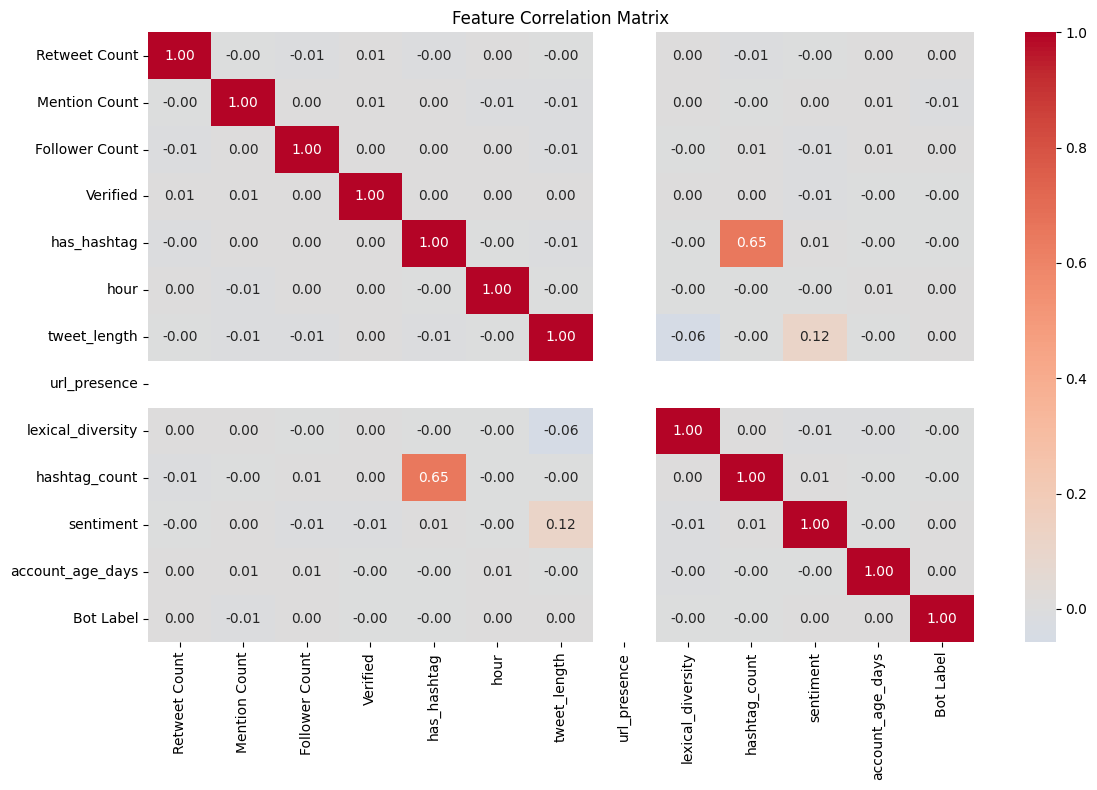

In [90]:
# Preview the full feature matrix and check correlation with label
feature_cols = [
    'Retweet Count', 'Mention Count', 'Follower Count', 'Verified',
    'has_hashtag', 'hour',
    'tweet_length', 'url_presence', 'lexical_diversity', 'hashtag_count',
    'sentiment', 'account_age_days',
    'Bot Label'
]

feature_df = df[feature_cols].copy()
feature_df['Verified'] = feature_df['Verified'].astype(int)

print(feature_df.shape)
print(feature_df.head())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(feature_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Model Training

In [91]:
from sklearn.model_selection import train_test_split

X = feature_df.drop(columns=['Bot Label'])
y = feature_df['Bot Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Bot rate — train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}")

Train: 40000 rows  |  Test: 10000 rows
Bot rate — train: 0.500  |  test: 0.500


### Logistic Regression (Baseline)

Logistic Regression — F1: 0.5022  |  ROC-AUC: 0.4887


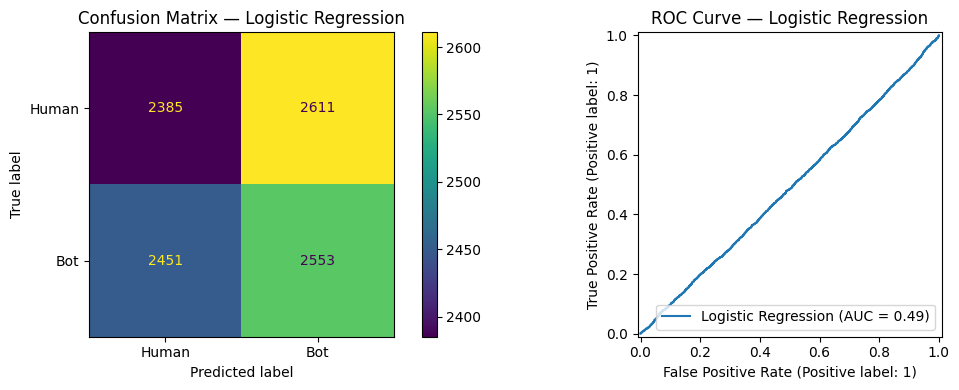

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression — F1: {f1_lr:.4f}  |  ROC-AUC: {auc_lr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Human', 'Bot'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

### Random Forest

Random Forest      — F1: 0.4961  |  ROC-AUC: 0.5016


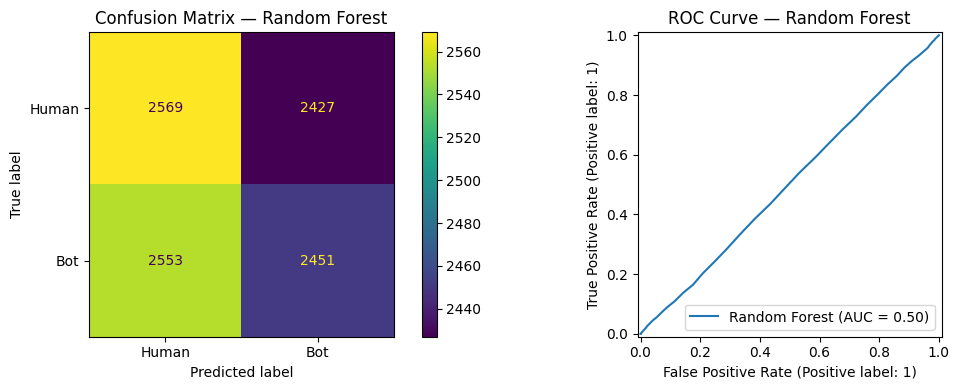

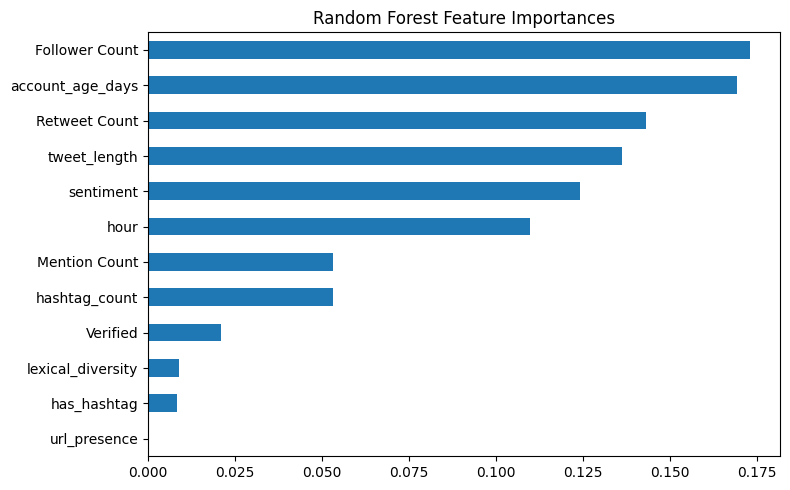

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest      — F1: {f1_rf:.4f}  |  ROC-AUC: {auc_rf:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Human', 'Bot'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1], name='Random Forest')
axes[1].set_title('ROC Curve — Random Forest')
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 5), title='Random Forest Feature Importances')
plt.tight_layout()
plt.show()

### XGBoost

In [94]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kaavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


XGBoost            — F1: 0.5022  |  ROC-AUC: 0.4928


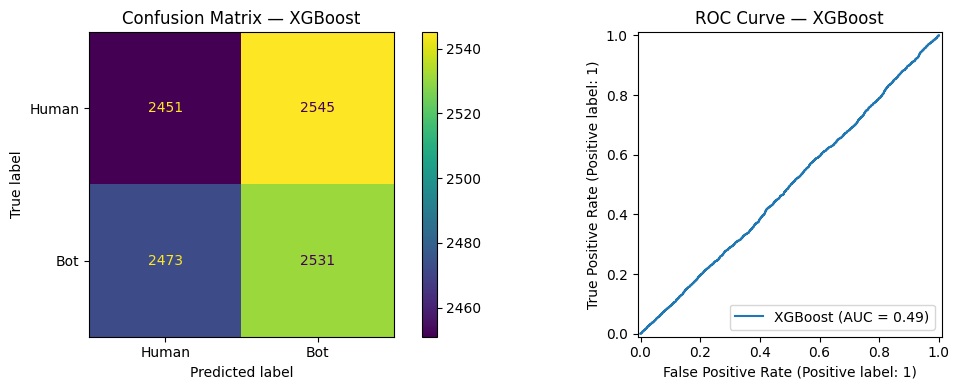

In [95]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost            — F1: {f1_xgb:.4f}  |  ROC-AUC: {auc_xgb:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['Human', 'Bot'], ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost')
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[1], name='XGBoost')
axes[1].set_title('ROC Curve — XGBoost')
plt.tight_layout()
plt.show()

### Model Comparison

                     F1 Score  ROC-AUC
Model                                 
Logistic Regression    0.5022   0.4887
Random Forest          0.4961   0.5016
XGBoost                0.5022   0.4928


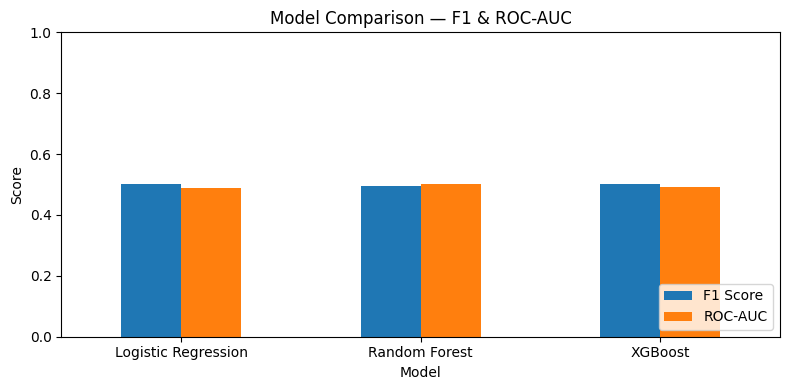

In [96]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'ROC-AUC': [auc_lr, auc_rf, auc_xgb]
}).set_index('Model').round(4)

print(results)

results.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), rot=0)
plt.title('Model Comparison — F1 & ROC-AUC')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## SHAP Explainability

In [97]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kaavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


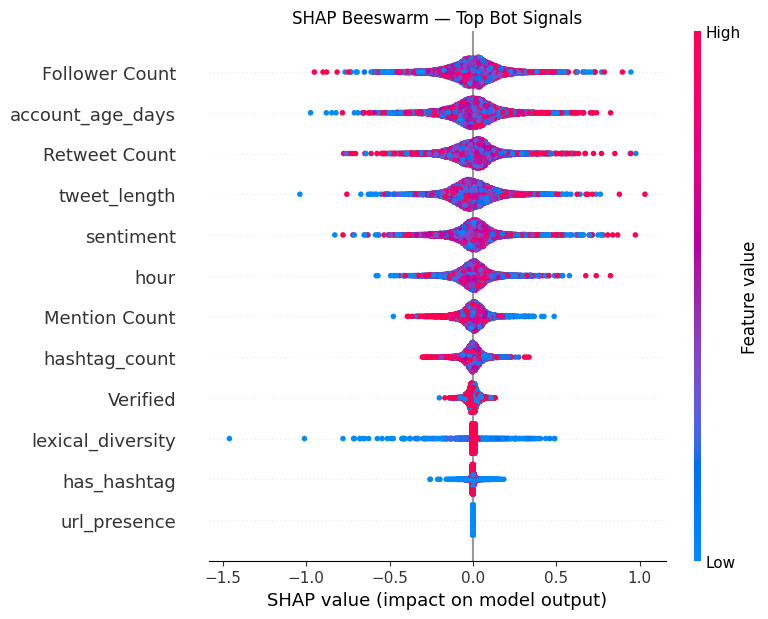

In [98]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot — top bot signals
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Top Bot Signals')
plt.tight_layout()
plt.show()

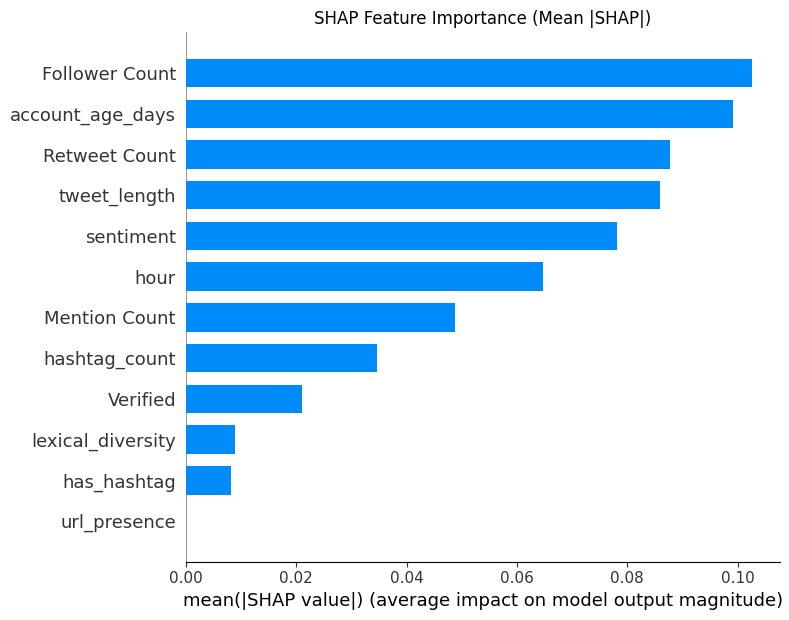

In [99]:
# Bar plot — mean absolute SHAP values (overall feature importance)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.show()

## Save Model

In [100]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("model.pkl and scaler.pkl saved.")

model.pkl and scaler.pkl saved.
